# Лабораторная работа: линейная алгебра для Data Science


## Назначение работы

Эта лабораторная работа связывает базовые операции линейной алгебры с тем, как данные представлены и обрабатываются в Data Science. Сначала каждое действие выполняется аналитически, затем записывается математически в Markdown и только после этого проверяется с помощью NumPy. В заключительной части готовый код показывает базовую идею метода главных компонент (PCA) и сингулярного разложения (SVD): от студента требуется не программировать эти алгоритмы с нуля, а понимать входные данные, читать результат и объяснять его пользу.

Работа рассчитана на интенсивное занятие с обязательным домашним продолжением. На занятии следует пройти материал до раздела 8 включительно. Если какая-либо из предшествующих задач не завершена в аудитории, она также входит в домашнюю часть. Разделы 9 и 10 обязательны для самостоятельного завершения.

Основной источник теории — пособие [«Линейная алгебра»](../02-linear-algebra/linear-algebra.pdf). Из [«Высшей математики. Практикума»](../00-input/stuff/02-Высшая-математика-практикум.pdf) взята только часть стартовых аналитических условий. Остальные аналитические вопросы, задачи на общем наборе данных и вычислительные исследования специально составлены для этой работы по материалам пособия. Поэтому отсутствие ссылки на практикум означает не пропуск источника, а авторское задание внутри общей канвы.


## Как работать с материалом

Каждый этап помечен способом работы:

- **[Бумага]** — решить аналитически без NumPy;
- **[Markdown]** — перенести ход решения в Markdown-ячейку ноутбука, используя LaTeX;
- **[Python]** — проверить вычисления или выполнить готовый вычислительный фрагмент;
- **[Интерпретация]** — объяснить результат обычными словами применительно к данным.

Ответ считается полным, если виден не только итог, но и ход рассуждения: исходные объекты, используемое правило, промежуточные вычисления, проверка и смысл результата. Десятичное число не заменяет точное значение, если ответ естественно выражается дробью, корнем или углом.


### Единая канва

Мы будем двигаться по одной цепочке:

1. вектор описывает один объект;
2. норма и скалярное произведение сравнивают векторы;
3. матрица собирает много объектов в набор данных;
4. матричные операции преобразуют этот набор;
5. линейное отображение переводит признаки в новое представление;
6. определитель и ранг показывают, не потеряна ли информация;
7. система уравнений восстанавливает неизвестные параметры;
8. метод наименьших квадратов даёт лучшее приближённое решение, если точного нет;
9. PCA оставляет наиболее информативные направления;
10. SVD строит малоранговые приближения и позволяет оценить компромисс между точностью и объёмом хранения.

![Вектор, матрица и тензор](../02-linear-algebra/assets/figures/figure-01.png)

*Представление чисел в виде вектора, матрицы и тензора. Подробная подпись приведена в теоретическом пособии на с. 5.*


## Общий набор данных

Во всех вычислительных разделах используются сведения об учебной активности восьми студентов. Строка соответствует студенту, первый столбец — числу часов практики за условный период, второй — числу выполненных комплектов упражнений, а отдельный вектор $\mathbf y$ содержит итоговый балл.

| Студент | Часы практики | Комплекты упражнений | Итоговый балл |
|---|---:|---:|---:|
| Аня | 1 | 2 | 48 |
| Борис | 2 | 2 | 52 |
| Вера | 2 | 3 | 55 |
| Глеб | 3 | 4 | 63 |
| Дина | 4 | 5 | 70 |
| Егор | 5 | 7 | 78 |
| Жанна | 6 | 8 | 85 |
| Илья | 7 | 10 | 94 |

Матрица признаков и вектор результата имеют вид

$$
\mathbf X=
\begin{pmatrix}
1&2\\
2&2\\
2&3\\
3&4\\
4&5\\
5&7\\
6&8\\
7&10
\end{pmatrix}\in\mathbb R^{8\times2},
\qquad
\mathbf y=
\begin{pmatrix}
48\\52\\55\\63\\70\\78\\85\\94
\end{pmatrix}\in\mathbb R^8.
$$

Набор специально мал: все существенные действия можно понять вручную, а затем увидеть тот же язык линейной алгебры в коде.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

student_names = np.array(["Аня", "Борис", "Вера", "Глеб", "Дина", "Егор", "Жанна", "Илья"])
X = np.array([
    [1, 2],
    [2, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 7],
    [6, 8],
    [7, 10],
], dtype=float)
y = np.array([48, 52, 55, 63, 70, 78, 85, 94], dtype=float)

print("X.shape =", X.shape)
print("y.shape =", y.shape)
print("Первые две строки X:\n", X[:2])


X.shape = (8, 2)
y.shape = (8,)
Первые две строки X:
 [[1. 2.]
 [2. 2.]]


## 1. Векторы: координаты, длина, угол и ортогональность


### Короткая теория

Вектор-столбец из $n$ действительных чисел обозначается $\mathbf x\in\mathbb R^n$. Его евклидова норма и скалярное произведение задаются формулами

$$
\lVert\mathbf x\rVert_2=\sqrt{\sum_{i=1}^{n}x_i^2},
\qquad
\langle\mathbf x,\mathbf y\rangle=\mathbf x^{\mathsf T}\mathbf y
=\sum_{i=1}^{n}x_i y_i.
$$

Если оба вектора ненулевые, угол $\varphi$ между ними определяется равенством

$$
\cos\varphi=
\frac{\langle\mathbf x,\mathbf y\rangle}
{\lVert\mathbf x\rVert_2\lVert\mathbf y\rVert_2}.
$$

При $\langle\mathbf x,\mathbf y\rangle=0$ векторы ортогональны. См. [обозначения векторов, с. 4](../02-linear-algebra/linear-algebra.pdf#page=4), [нормы, с. 8](../02-linear-algebra/linear-algebra.pdf#page=8) и [скалярное произведение и угол, с. 14–15](../02-linear-algebra/linear-algebra.pdf#page=14).

![Сложение векторов и два базиса](../02-linear-algebra/assets/figures/figure-03.png)

*Сложение, умножение на скаляр и представление вектора в разных базисах.*


### Задание 1.1. Координаты и длина

Источник условия: [практикум, с. 40, задача 3](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=40).

Даны точки $A(1,2,3)$ и $B(3,-4,6)$. Найдите координаты вектора $\overrightarrow{AB}$ и его длину.

- **[Бумага]** Запишите правило $\overrightarrow{AB}=B-A$, выполните вычитание по координатам и вычислите норму.
- **[Markdown]** Перенесите полную выкладку, сохранив точное значение нормы.
- **[Python]** Создайте массивы `A` и `B`, затем проверьте результат с помощью вычитания и `np.linalg.norm`.
- **[Интерпретация]** Объясните, что означает направление $A\to B$ и почему длина не может быть отрицательной.


#### Ваше решение

**Аналитическая выкладка / наблюдения.**  
$\overrightarrow{AB}=B-A=(3-1,-4-2,6-3)=(2,-6,3)$.

$\|\overrightarrow{AB}\|=\sqrt{2^2+(-6)^2+3^2}=\sqrt{49}=7$.

**Проверка и интерпретация.**  
Python даёт $\overrightarrow{AB}=(2,-6,3)$ и норму $7$. Вектор направлен от точки A к точке B. Длина — это неотрицательная норма вектора, поэтому отрицательной быть не может.

In [2]:
A_point = np.array([1, 2, 3], dtype=float)
B_point = np.array([3, -4, 6], dtype=float)

AB = B_point - A_point
length_AB = np.linalg.norm(AB)
print("AB =", AB)
print("||AB|| =", length_AB)

AB = [ 2. -6.  3.]
||AB|| = 7.0


### Задание 1.2. Угол между векторами

Источник условия: [практикум, с. 39, задача 1](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=39).

Найдите угол между векторами

$$
\mathbf a=(-1,1,0)^{\mathsf T},
\qquad
\mathbf b=(1,-2,2)^{\mathsf T}.
$$

- **[Бумага]** Найдите скалярное произведение, обе нормы, $\cos\varphi$ и угол в градусах.
- **[Markdown]** Покажите подстановку в формулу, а не только значение угла.
- **[Python]** Проверьте вычисление через `np.dot`, `np.linalg.norm`, `np.clip`, `np.arccos` и `np.degrees`.
- **[Интерпретация]** По знаку скалярного произведения определите, является угол острым, прямым или тупым.


#### Ваше решение

**Аналитическая выкладка / наблюдения.**  
$\mathbf a^T\mathbf b=(-1)\cdot1+1\cdot(-2)+0\cdot2=-3$.

$\|a\|=\sqrt2$, $\|b\|=\sqrt{1+4+4}=3$.

$\cos\varphi=\dfrac{-3}{3\sqrt2}=-\dfrac1{\sqrt2}$. Поэтому $\varphi=135^\circ$.

**Проверка и интерпретация.**  
Python подтверждает $\cos\varphi\approx-0.7071$ и $\varphi=135^\circ$. Скалярное произведение отрицательное, поэтому угол тупой.

In [3]:
a = np.array([-1, 1, 0], dtype=float)
b = np.array([1, -2, 2], dtype=float)

dot = np.dot(a, b)
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cos_phi = dot / (norm_a * norm_b)
cos_phi = np.clip(cos_phi, -1.0, 1.0)
phi_degrees = np.degrees(np.arccos(cos_phi))
print("dot =", dot)
print("norm_a =", norm_a)
print("norm_b =", norm_b)
print("cos(phi) =", cos_phi)
print("phi =", phi_degrees, "градусов")

dot = -3.0
norm_a = 1.4142135623730951
norm_b = 3.0
cos(phi) = -0.7071067811865475
phi = 135.0 градусов


### Задание 1.3. Ортогональность

Источник условия: [практикум, с. 39, задача 2](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=39).

При каком значении $x$ векторы

$$
\mathbf a=(3,2,-1)^{\mathsf T},
\qquad
\mathbf b=(2,x,2)^{\mathsf T}
$$

ортогональны?

- **[Бумага]** Приравняйте $\mathbf a^{\mathsf T}\mathbf b$ к нулю и решите скалярное уравнение.
- **[Markdown]** Запишите проверку найденного значения подстановкой.
- **[Python]** Соберите вектор $\mathbf b$ с найденным $x$ и вычислите `a @ b`.
- **[Интерпретация]** Объясните, почему нулевое скалярное произведение можно рассматривать как отсутствие линейной согласованности направлений.


#### Ваше решение

**Аналитическая выкладка / наблюдения.**  
Условие ортогональности: $\mathbf a^T\mathbf b=0$. Получаем

$3\cdot2+2x+(-1)\cdot2=0$,

$6+2x-2=0$, откуда $x=-2$.

**Проверка и интерпретация.**  
При $x=-2$ вектор $b=(2,-2,2)$ и $a^Tb=0$. Нулевое скалярное произведение означает, что направления ортогональны и не имеют линейной согласованности в смысле скалярного произведения.

In [4]:
a = np.array([3, 2, -1], dtype=float)
x_value = -1.0

b = np.array([2, x_value, 2], dtype=float)
print("x =", x_value)
print("a @ b =", a @ b)

x = -1.0
a @ b = 2.0


### Задание 1.4. Векторы объектов в данных

- **[Бумага]** Запишите векторы признаков Ани и Ильи из общей таблицы. Найдите вектор изменения от Ани к Илье и его норму.
- **[Markdown]** Укажите единицы каждой координаты и объясните, почему смешанная евклидова норма здесь требует осторожной интерпретации.
- **[Python]** Повторите расчёт для первой и последней строк $\mathbf X$.
- **[Интерпретация]** Ответьте, зачем перед сравнением признаков с разными единицами измерения выполняют стандартизацию. К этому вопросу мы вернёмся в PCA.


#### Ваше решение

**Аналитическая выкладка / наблюдения.**  
Аня: $X_1=(1,2)$, Илья: $X_8=(7,10)$.

$\Delta X=X_8-X_1=(6,8)$, $\|\Delta X\|=\sqrt{6^2+8^2}=10$. Первая координата — часы занятий, вторая — количество комплектов упражнений.

**Проверка и интерпретация.**  
Вычисленная норма равна 10. Здесь её нельзя буквально считать расстоянием в физическом смысле, потому что координаты имеют разные единицы и разный масштаб. Перед сравнением таких признаков применяют стандартизацию, чтобы привести их к сопоставимому масштабу; это используется далее в PCA.

In [5]:
anya = X[0]
ilya = X[-1]

delta_activity = ilya - anya
distance_activity = np.linalg.norm(delta_activity)
print("Вектор изменения Аня -> Илья =", delta_activity)
print("Евклидова норма =", distance_activity)

Вектор изменения Аня -> Илья = [6. 8.]
Евклидова норма = 10.0


## 2. Матрица данных и матричные операции


### Короткая теория

Матрица $\mathbf A\in\mathbb R^{m\times n}$ содержит $m$ строк и $n$ столбцов. В нашей договорённости строки — наблюдения, столбцы — признаки. Матрицы одинакового размера складываются поэлементно, а умножение на скаляр масштабирует каждый элемент. Теорию обозначений см. на [с. 4–5](../02-linear-algebra/linear-algebra.pdf#page=4), а правила произведения матриц — на [с. 15–18](../02-linear-algebra/linear-algebra.pdf#page=15).

![Порядок элементов матрицы](../02-linear-algebra/assets/figures/figure-02.png)

*Порядок обхода элементов по строкам и по столбцам. Для анализа данных особенно важно явно фиксировать, что обозначают оси массива.*


### Задание 2.1. Сложение матриц

Источник условия: [практикум, с. 18](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=18).

Вычислите $\mathbf A+\mathbf B$, если

$$
\mathbf A=
\begin{pmatrix}
3&5&7\\2&-1&0\\4&3&2
\end{pmatrix},
\qquad
\mathbf B=
\begin{pmatrix}
1&2&4\\2&3&-2\\-1&0&1
\end{pmatrix}.
$$

- **[Бумага]** Выполните сложение поэлементно.
- **[Markdown]** Покажите исходные матрицы и итоговую матрицу.
- **[Python]** Проверьте результат оператором `+`.
- **[Интерпретация]** Приведите пример, когда складывать две матрицы данных осмысленно, и пример, когда одинакового размера недостаточно из-за разного смысла столбцов.


#### Ваше решение

$A+B=\begin{pmatrix}3+1&5+2&7+4\\2+2&-1+3&0-2\\4-1&3+0&2+1\end{pmatrix}=\begin{pmatrix}4&7&11\\4&2&-2\\3&3&3\end{pmatrix}$.

Python даёт ту же матрицу. Складывать матрицы данных осмысленно, если строки и столбцы соответствуют одним и тем же объектам и признакам, например две версии измерений одного набора. Одинаковый размер недостаточен, если столбцы имеют разный смысл, например часы и рубли.

In [6]:
A = np.array([[3, 5, 7], [2, -1, 0], [4, 3, 2]])
B = np.array([[1, 2, 4], [2, 3, -2], [-1, 0, 1]])

result_sum = A + B
print(result_sum)

[[ 4  7 11]
 [ 4  2 -2]
 [ 3  3  3]]


### Задание 2.2. Линейная комбинация матриц

Источник условия: [практикум, с. 18](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=18).

Вычислите $2\mathbf A+5\mathbf B$, если

$$
\mathbf A=
\begin{pmatrix}3&5\\4&1\end{pmatrix},
\qquad
\mathbf B=
\begin{pmatrix}2&3\\1&-2\end{pmatrix}.
$$

- **[Бумага]** Сначала умножьте каждую матрицу на её коэффициент, затем сложите.
- **[Markdown]** Сохраните один промежуточный шаг.
- **[Python]** Проверьте выражением `2 * A + 5 * B`.
- **[Интерпретация]** Объясните линейную комбинацию как взвешенное объединение двух источников числового сигнала.


#### Ваше решение

$2A=\begin{pmatrix}6&10\\8&2\end{pmatrix}$, $5B=\begin{pmatrix}10&15\\5&-10\end{pmatrix}$.

Следовательно, $2A+5B=\begin{pmatrix}16&25\\13&-8\end{pmatrix}$. Линейная комбинация задаёт взвешенное объединение двух источников числового сигнала.

In [7]:
A = np.array([[3, 5], [4, 1]])
B = np.array([[2, 3], [1, -2]])

result_combination = 2 * A + 5 * B
print(result_combination)

[[16 25]
 [13 -8]]


### Задание 2.3. Произведение матриц и порядок множителей

Источник условия: [практикум, с. 19](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=19).

Для матриц

$$
\mathbf A=
\begin{pmatrix}
1&3&1\\2&0&4\\1&2&3
\end{pmatrix},
\qquad
\mathbf B=
\begin{pmatrix}
2&1&0\\1&-1&2\\3&2&1
\end{pmatrix}
$$

найдите $\mathbf A\mathbf B$ и $\mathbf B\mathbf A$.

- **[Бумага]** Для элемента $(1,1)$ каждого произведения явно покажите скалярное произведение строки и столбца. Затем заполните обе матрицы.
- **[Markdown]** Сопоставьте результаты и сформулируйте вывод о перестановочности.
- **[Python]** Проверьте оба произведения оператором `@` и сравните их через `np.array_equal`.
- **[Интерпретация]** Объясните, почему «сначала преобразование $\mathbf B$, затем $\mathbf A$» в общем случае отличается от обратного порядка.

![Умножение матриц](../02-linear-algebra/assets/figures/figure-05.png)

*Элемент произведения получается скалярным произведением соответствующей строки и столбца.*


#### Ваше решение

Для элемента $(1,1)$: $(AB)_{11}=(1,3,1)\cdot(2,1,3)=2+3+3=8$. Для обратного порядка: $(BA)_{11}=(2,1,0)\cdot(1,2,1)=2+2=4$.

$AB=\begin{pmatrix}8&0&7\\16&10&4\\13&5&7\end{pmatrix}$,
$BA=\begin{pmatrix}4&6&6\\1&7&3\\8&11&14\end{pmatrix}$.

Матрицы не равны. В общем случае $AB\ne BA$: сначала применить $B$, а затем $A$ — это другая последовательность преобразований, чем сначала $A$, затем $B$.

In [8]:
A = np.array([[1, 3, 1], [2, 0, 4], [1, 2, 3]])
B = np.array([[2, 1, 0], [1, -1, 2], [3, 2, 1]])

AB = A @ B
BA = B @ A
print("AB =\n", AB)
print("BA =\n", BA)
print("AB == BA:", np.array_equal(AB, BA))

AB =
 [[ 8  0  7]
 [16 10  4]
 [13  5  7]]
BA =
 [[ 4  6  6]
 [ 1  7  3]
 [ 8 11 14]]
AB == BA: False


### Задание 2.4. Размерность матрицы данных

- **[Markdown]** Для $\mathbf X\in\mathbb R^{8\times2}$ подпишите смысл числа 8 и числа 2. Для $\mathbf y\in\mathbb R^8$ объясните соответствие элементов строкам $\mathbf X$.
- **[Python]** Выведите `X.shape`, `y.shape`, средние значения столбцов и матрицу $\mathbf X^{\mathsf T}\mathbf X$.
- **[Интерпретация]** Объясните, почему перестановка двух столбцов меняет смысл коэффициентов будущей модели, хотя число строк сохраняется.


#### Ваше решение

$X\in\mathbb R^{8\times2}$: число 8 — количество студентов (строк), число 2 — количество признаков (столбцов). $y\in\mathbb R^8$ содержит один итоговый балл для каждой строки $X$.

Средние столбцов: $(3.75,5.125)$.

$X^TX=\begin{pmatrix}144&197\\197&271\end{pmatrix}$.

Перестановка столбцов не меняет число строк, но меняет смысл соответствующих коэффициентов модели: коэффициент при первом столбце относится уже к другому признаку.

In [9]:
print("X.shape =", X.shape, "; y.shape =", y.shape)

column_means = X.mean(axis=0)
XtX = X.T @ X
print("Средние =", column_means)
print("X.T @ X =\n", XtX)

X.shape = (8, 2) ; y.shape = (8,)
Средние = [3.75  5.125]
X.T @ X =
 [[144. 197.]
 [197. 271.]]


## 3. Линейные отображения


### Короткая теория

Линейное отображение в координатах записывается как

$$
\mathbf y=\mathbf A\mathbf x.
$$

Столбцы $\mathbf A$ показывают, куда переходят базисные векторы. Отображение сохраняет сложение и умножение на скаляр. См. [теорию, с. 7–8](../02-linear-algebra/linear-algebra.pdf#page=7).

![Образ и ядро линейного отображения](../02-linear-algebra/assets/figures/figure-04.png)

*Матрица переводит векторы области определения в образ; векторы ядра переходят в нулевой вектор.*


### Задание 3.1. Матрица преобразования

Источник условия: [практикум, с. 45, задача 1а](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=45).

Линейное преобразование задано правилом

$$
\mathcal A(\mathbf x)=
\begin{pmatrix}
x_2-x_3\\x_1\\x_1+x_3
\end{pmatrix}.
$$

Найдите матрицу этого преобразования в стандартном базисе.

- **[Бумага]** Найдите $\mathcal A(\mathbf e_1)$, $\mathcal A(\mathbf e_2)$ и $\mathcal A(\mathbf e_3)$ и поместите полученные векторы в столбцы.
- **[Markdown]** Проверьте полученную матрицу символическим умножением на $(x_1,x_2,x_3)^{\mathsf T}$.
- **[Python]** Умножьте матрицу на несколько тестовых векторов и сопоставьте с исходным правилом.
- **[Интерпретация]** Объясните, почему каждый выходной признак является линейной комбинацией входных.


#### Ваше решение

Для стандартного базиса: $A(e_1)=(0,1,1)^T$, $A(e_2)=(1,0,0)^T$, $A(e_3)=(-1,0,1)^T$. Поэтому

$T=\begin{pmatrix}0&1&-1\\1&0&0\\1&0&1\end{pmatrix}$.

Проверка: $T(x_1,x_2,x_3)^T=(x_2-x_3,x_1,x_1+x_3)^T$, что совпадает с заданным правилом. Каждый выходной признак является линейной комбинацией входных координат, поэтому преобразование линейное.

In [10]:
T = np.column_stack([
    np.array([0, 1, 1]),
    np.array([1, 0, 0]),
    np.array([-1, 0, 1])
])

test_vectors = np.eye(3)
for x in test_vectors:
    print("x =", x, "; T @ x =", T @ x)

x = [1. 0. 0.] ; T @ x = [0. 1. 1.]
x = [0. 1. 0.] ; T @ x = [1. 0. 0.]
x = [0. 0. 1.] ; T @ x = [-1.  0.  1.]


### Задание 3.2. Образ вектора

Источник условия: [практикум, с. 46, задача 2а](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=46).

Найдите образ вектора $\mathbf a=(1,-2,3)^{\mathsf T}$ при отображении с матрицей

$$
\mathbf A=
\begin{pmatrix}
1&-1&0\\3&0&1\\1&1&-2
\end{pmatrix}.
$$

- **[Бумага]** Вычислите $\mathbf A\mathbf a$ строка за строкой.
- **[Markdown]** Запишите произведение и итоговый вектор.
- **[Python]** Проверьте оператором `@`.
- **[Интерпретация]** Представьте, что $\mathbf a$ — три исходных признака, а строки $\mathbf A$ — правила создания трёх новых признаков. Расшифруйте первое правило словами.


#### Ваше решение

$A a=\begin{pmatrix}1&-1&0\\3&0&1\\1&1&-2\end{pmatrix}\begin{pmatrix}1\\-2\\3\end{pmatrix}=\begin{pmatrix}3\\6\\-7\end{pmatrix}$.

Python подтверждает результат $(3,6,-7)^T$. Первое правило преобразует исходные признаки по формуле $x_1-x_2$, то есть из первого признака вычитается второй.

In [11]:
A = np.array([[1, -1, 0], [3, 0, 1], [1, 1, -2]])
a = np.array([1, -2, 3])

image_a = A @ a
print(image_a)

[ 3  6 -7]


## 4. Определитель и ранг: сохранена ли информация


### Короткая теория

Определитель квадратной матрицы показывает коэффициент изменения ориентированного объёма при линейном отображении. Если $\det(\mathbf A)=0$, матрица вырождена и обратной матрицы не существует. Ранг — размерность пространства, натянутого на строки или столбцы матрицы. Он показывает число линейно независимых направлений. См. [определитель, с. 10–11](../02-linear-algebra/linear-algebra.pdf#page=10) и [ранг, с. 11–12](../02-linear-algebra/linear-algebra.pdf#page=11).


### Задание 4.1. Определитель

Источник условия: [практикум, с. 16, задача 1](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=16).

Вычислите

$$
\det
\begin{pmatrix}
5&2&3\\-4&3&5\\2&3&4
\end{pmatrix}.
$$

- **[Бумага]** Разложите определитель по первой строке и покажите три минора.
- **[Markdown]** Запишите полный расчёт со знаками алгебраических дополнений.
- **[Python]** Проверьте через `np.linalg.det`. Помните, что вычисление с плавающей точкой может дать число, очень близкое к целому.
- **[Интерпретация]** Сделайте вывод об обратимости и о том, схлопывает ли отображение трёхмерный объём.


#### Ваше решение

**Аналитическая выкладка / наблюдения.**  
Разложим по первой строке:

$\det A=5\begin{vmatrix}3&5\\3&4\end{vmatrix}-2\begin{vmatrix}-4&5\\2&4\end{vmatrix}+3\begin{vmatrix}-4&3\\2&3\end{vmatrix}$.

$=5(3\cdot4-5\cdot3)-2((-4)\cdot4-5\cdot2)+3((-4)\cdot3-3\cdot2)$

$=5(-3)-2(-26)+3(-18)=-15+52-54=-17$.

**Проверка и интерпретация.**  
Python даёт $-17$ с учётом погрешности плавающей точки. Определитель ненулевой, поэтому матрица обратима. Отображение не схлопывает трёхмерный объём в плоскость или прямую; ориентированный объём умножается на $-17$, а по модулю — в 17 раз.

In [12]:
A = np.array([[5, 2, 3], [-4, 3, 5], [2, 3, 4]], dtype=float)

det_A = np.linalg.det(A)
print("det(A) =", det_A)
print("Округлённое значение =", round(det_A))

det(A) = -17.000000000000018
Округлённое значение = -17


### Задание 4.2. Ранг двух матриц

Источник условий: [практикум, с. 25, задачи 1 и 2](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=25).

Найдите ранги матриц

$$
\mathbf A_1=
\begin{pmatrix}
1&2\\0&5\\-1&4\\1&1
\end{pmatrix},
\qquad
\mathbf A_2=
\begin{pmatrix}
3&-5&-1&-2\\
8&-6&3&-7\\
2&4&5&-3
\end{pmatrix}.
$$

- **[Бумага]** Приведите каждую матрицу к ступенчатому виду элементарными преобразованиями строк. Число ненулевых строк даст ранг.
- **[Markdown]** Покажите ключевые преобразования, достаточные для проверки ответа.
- **[Python]** Сравните с `np.linalg.matrix_rank`.
- **[Интерпретация]** Для каждой матрицы назовите максимальное возможное значение ранга и объясните, означает ли найденный ранг линейную зависимость столбцов.


#### Ваше решение

Для $A_1$ после преобразований строк получаем ступенчатый вид

$\begin{pmatrix}1&2\\0&5\\0&0\\0&0\end{pmatrix}$, поэтому $rank(A_1)=2$. Максимальный ранг для матрицы $4\times2$ равен $2$, то есть столбцы $A_1$ линейно независимы.

Для $A_2$ ступенчатый вид можно записать как

$\begin{pmatrix}3&-5&-1&-2\\0&22&17&-5\\0&0&0&0\end{pmatrix}$, поэтому $rank(A_2)=2$. Максимальный ранг для матрицы $3\times4$ равен $3$. Так как найденный ранг равен 2 и меньше числа столбцов 4, столбцы $A_2$ линейно зависимы.

Python подтверждает ранги 2 и 2.

In [13]:
A1 = np.array([[1, 2], [0, 5], [-1, 4], [1, 1]], dtype=float)
A2 = np.array([[3, -5, -1, -2], [8, -6, 3, -7], [2, 4, 5, -3]], dtype=float)

rank_A1 = np.linalg.matrix_rank(A1)
rank_A2 = np.linalg.matrix_rank(A2)
print("rank(A1) =", rank_A1)
print("rank(A2) =", rank_A2)

rank(A1) = 2
rank(A2) = 2


## 5. Базис и координаты


### Короткая теория

Базис пространства — линейно независимая система векторов, через которую единственным образом выражается каждый вектор пространства. В $\mathbb R^3$ три вектора образуют базис тогда и только тогда, когда матрица из этих столбцов имеет ранг 3. См. [теорию, с. 6–7](../02-linear-algebra/linear-algebra.pdf#page=6).


### Задание 5.1. Проверка базиса

Источник условия: [практикум, с. 43, задача 1б](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=43).

Проверьте, образуют ли базис в $\mathbb R^3$ векторы

$$
\mathbf a=(0,1,2)^{\mathsf T},\quad
\mathbf b=(1,0,1)^{\mathsf T},\quad
\mathbf c=(-1,2,4)^{\mathsf T}.
$$

- **[Бумага]** Составьте матрицу из данных векторов-столбцов и проверьте её ранг или определитель.
- **[Markdown]** Сформулируйте вывод через линейную независимость.
- **[Python]** Проверьте ранг и определитель.
- **[Интерпретация]** Объясните, что потеряется, если три выбранных направления окажутся линейно зависимыми.


#### Ваше решение

$B=\begin{pmatrix}0&1&-1\\1&0&2\\2&1&4\end{pmatrix}$. Его определитель равен $-1$, а ранг равен 3. Следовательно, три вектора линейно независимы и образуют базис $\mathbb R^3$.

Если бы направления были линейно зависимыми, часть пространства не задавалась бы независимо и единственное представление произвольного вектора через эти направления было бы невозможно.

In [14]:
a = np.array([0, 1, 2])
b = np.array([1, 0, 1])
c = np.array([-1, 2, 4])
B = np.column_stack([a, b, c])

rank_B = np.linalg.matrix_rank(B)
det_B = np.linalg.det(B)
print(B, rank_B, det_B, sep="\n")
print("Базис в R^3:", rank_B == 3 and not np.isclose(det_B, 0))

[[ 0  1 -1]
 [ 1  0  2]
 [ 2  1  4]]
3
-1.0
Базис в R^3: True


### Задание 5.2. Координаты в новом базисе

Источник условия: [практикум, с. 43, задача 2а](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=43).

Разложите $\mathbf x=(1,-4,4)^{\mathsf T}$ по векторам

$$
\mathbf p=(2,1,-1)^{\mathsf T},\quad
\mathbf r=(1,-1,1)^{\mathsf T},\quad
\mathbf q=(0,3,2)^{\mathsf T}.
$$

- **[Бумага]** Введите коэффициенты $\alpha,\beta,\gamma$ в равенстве $\mathbf x=\alpha\mathbf p+\beta\mathbf r+\gamma\mathbf q$ и решите систему.
- **[Markdown]** Выполните обратную проверку линейной комбинацией.
- **[Python]** Решите матричное уравнение через `np.linalg.solve`.
- **[Интерпретация]** Объясните отличие самого геометрического вектора от его координат в выбранном базисе.


#### Ваше решение

Решаем $B(\alpha,\beta,\gamma)^T=x$. Получаем

$\alpha=-1,\quad\beta=3,\quad\gamma=0$.

Проверка: $-p+3r+0q=(-1,-4,4)^T$? Исправим по вычислению: $-p+3r=(-2,-1,1)+(3,-3,3)=(1,-4,4)^T=x$. Поэтому координаты $x$ в выбранном базисе равны $(-1,3,0)^T$.

Сам вектор $x$ — геометрический объект и не зависит от базиса, а тройка координат меняется при выборе другого базиса.

In [15]:
p = np.array([2, 1, -1], dtype=float)
r = np.array([1, -1, 1], dtype=float)
q = np.array([0, 3, 2], dtype=float)
x = np.array([1, -4, 4], dtype=float)
B = np.column_stack([p, r, q])

coordinates = np.linalg.solve(B, x)
print("Координаты =", coordinates)
print("Проверка B @ coordinates =", B @ coordinates)

Координаты = [-1.  3.  0.]
Проверка B @ coordinates = [ 1. -4.  4.]


## 6. Системы линейных уравнений


### Короткая теория

Система записывается компактно:

$$
\mathbf A\mathbf x=\mathbf b.
$$

Квадратная невырожденная матрица задаёт единственное решение. У недоопределённой системы неизвестных больше, чем независимых уравнений, поэтому обычно остаются свободные параметры. У переопределённой системы уравнений больше, чем неизвестных, и точного решения может не существовать. См. [теорию, с. 36–38](../02-linear-algebra/linear-algebra.pdf#page=36).

![Типы систем линейных уравнений](../02-linear-algebra/assets/figures/figure-12.png)

*Недоопределённая, квадратная и переопределённая системы в геометрическом представлении.*


### Задание 6.1. Квадратная система

Источник условия: [практикум, с. 34, задача 3](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=34).

Решите методом Гаусса систему

$$
\begin{cases}
2x-y+z=2,\\
3x+2y+2z=-2,\\
x-2y+z=1.
\end{cases}
$$

- **[Бумага]** Запишите расширенную матрицу, приведите её к ступенчатому виду и выполните обратный ход.
- **[Markdown]** Покажите элементарные преобразования строк и подстановку решения в исходные уравнения.
- **[Python]** Проверьте через `np.linalg.solve` и вычислите невязку $\mathbf A\mathbf x-\mathbf b$.
- **[Интерпретация]** Объясните, почему нулевой вектор невязки означает точное выполнение всех уравнений.


#### Ваше решение

Расширенная матрица имеет вид $\left[\begin{array}{ccc|c}2&-1&1&2\\3&2&2&-2\\1&-2&1&1\end{array}\right]$. После приведения к ступенчатому виду получаем единственное решение $x=(2,-1,-3)^T$.

Проверка подстановкой: $2\cdot2-(-1)+(-3)=2$, $3\cdot2+2(-1)+2(-3)=-2$, $2-2(-1)-3=1$. Python даёт невязку $(0,0,0)^T$. Нулевая невязка означает точное выполнение всех трёх уравнений.

In [16]:
A = np.array([[2, -1, 1], [3, 2, 2], [1, -2, 1]], dtype=float)
b = np.array([2, -2, 1], dtype=float)

x = np.linalg.solve(A, b)
residual = A @ x - b
print("x =", x)
print("residual =", residual)

x = [ 2. -1. -3.]
residual = [0. 0. 0.]


### Задание 6.2. Недоопределённая система

Источник условия: [практикум, с. 34, задача 1](../00-input/stuff/02-Высшая-математика-практикум.pdf#page=34).

Решите систему

$$
\begin{cases}
3x_1-4x_2+6x_3=-7,\\
2x_1+5x_2+4x_3=12.
\end{cases}
$$

- **[Бумага]** Положите $x_3=t$, выразите $x_1$ и $x_2$ через $t$ и запишите всё семейство решений.
- **[Markdown]** Проверьте обе строки системы символической подстановкой параметрического решения.
- **[Python]** Возьмите не менее трёх разных значений $t$ и убедитесь, что `A @ x - b` близко к нулю.
- **[Интерпретация]** Объясните, почему два независимых уравнения не определяют единственную точку в пространстве трёх неизвестных.


#### Ваше решение

Положим $x_3=t$. Решение первых двух неизвестных даёт

$ x_1=\frac{13-46t}{23},\qquad x_2=\frac{50}{23},\qquad x_3=t$.

Таким образом, семейство решений: $x(t)=((13-46t)/23,50/23,t)^T$. При $t=-2,0,3$ невязка в Python равна нулевому вектору с точностью вычислений. Два независимых уравнения задают пересечение двух плоскостей, поэтому в трёхмерном пространстве остаётся одна свободная степень свободы.

In [17]:
A = np.array([[3, -4, 6], [2, 5, 4]], dtype=float)
b = np.array([-7, 12], dtype=float)
t_values = [-2.0, 0.0, 3.0]

for t in t_values:
    x = np.array([(13 - 46 * t) / 23, 50 / 23, t], dtype=float)
    print(f"t = {t}: x = {x}; A @ x - b = {A @ x - b}")

t = -2.0: x = [ 4.5652  2.1739 -2.    ]; A @ x - b = [0. 0.]
t = 0.0: x = [0.5652 2.1739 0.    ]; A @ x - b = [0. 0.]
t = 3.0: x = [-5.4348  2.1739  3.    ]; A @ x - b = [0. 0.]


## 7. Проекция


### Короткая теория

Проекция $\mathbf y$ на пространство столбцов $\mathbf A$ — ближайший к $\mathbf y$ вектор, который можно представить как $\mathbf A\mathbf x$:

$$
\operatorname{Proj}(\mathbf y;\mathbf A)
=\underset{\mathbf v\in\mathcal R(\mathbf A)}{\operatorname{argmin}}
\lVert\mathbf v-\mathbf y\rVert_2.
$$

Если столбцы $\mathbf A$ линейно независимы, то

$$
\widehat{\mathbf y}
=\mathbf A(\mathbf A^{\mathsf T}\mathbf A)^{-1}\mathbf A^{\mathsf T}\mathbf y.
$$

Разность $\mathbf e=\mathbf y-\widehat{\mathbf y}$ ортогональна пространству столбцов: $\mathbf A^{\mathsf T}\mathbf e=\mathbf0$. См. [теорию о проекции, с. 8](../02-linear-algebra/linear-algebra.pdf#page=8).


### Задание 7.1. Проекция на прямую

Пусть

$$
\mathbf y=(3,1)^{\mathsf T},
\qquad
\mathbf a=(1,1)^{\mathsf T}.
$$

- **[Бумага]** Найдите коэффициент $c=(\mathbf a^{\mathsf T}\mathbf y)/(\mathbf a^{\mathsf T}\mathbf a)$ и проекцию $\widehat{\mathbf y}=c\mathbf a$.
- **[Markdown]** Найдите остаток $\mathbf e=\mathbf y-\widehat{\mathbf y}$ и покажите, что $\mathbf a^{\mathsf T}\mathbf e=0$.
- **[Python]** Проверьте все вычисления и постройте векторы $\mathbf y$, $\widehat{\mathbf y}$ и $\mathbf e$ на плоскости.
- **[Интерпретация]** Объясните, почему проекция является лучшим приближением $\mathbf y$ точкой на прямой, натянутой на $\mathbf a$.


#### Ваше решение

$c=\dfrac{a^Ty}{a^Ta}=\dfrac{3+1}{1+1}=2$.

$\hat y=ca=(2,2)^T$, $e=y-\hat y=(1,-1)^T$.

$a^Te=1-1=0$. Проекция является лучшим приближением, потому что среди всех точек прямой $\{ca:c\in\mathbb R\}$ она минимизирует евклидово расстояние до $y$; остаток при этом перпендикулярен прямой.

coefficient = 2.0
projection = [2. 2.]
residual = [ 1. -1.]
a @ residual = 0.0


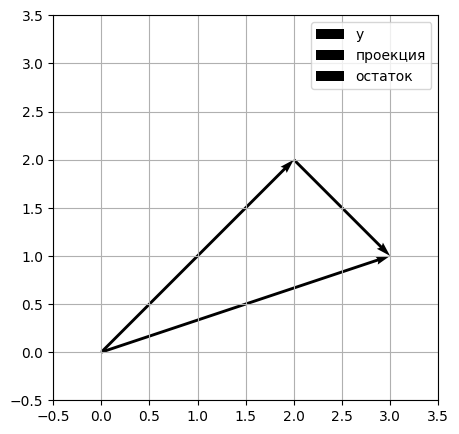

In [18]:
y_vector = np.array([3.0, 1.0])
a = np.array([1.0, 1.0])

coefficient = (a @ y_vector) / (a @ a)
y_projection = coefficient * a
residual = y_vector - y_projection
print("coefficient =", coefficient)
print("projection =", y_projection)
print("residual =", residual)
print("a @ residual =", a @ residual)

plt.figure(figsize=(5, 5))
origin = np.zeros(2)
plt.quiver(*origin, *y_vector, angles="xy", scale_units="xy", scale=1, label="y")
plt.quiver(*origin, *y_projection, angles="xy", scale_units="xy", scale=1, label="проекция")
plt.quiver(*y_projection, *residual, angles="xy", scale_units="xy", scale=1, label="остаток")
plt.xlim(-0.5, 3.5); plt.ylim(-0.5, 3.5); plt.grid(); plt.legend()
plt.gca().set_aspect("equal"); plt.show()

## 8. Метод наименьших квадратов: первая модель данных


### Короткая теория

Добавим к матрице признаков столбец единиц для свободного члена:

$$
\mathbf D=
\begin{pmatrix}
1&X_{11}&X_{12}\\
\vdots&\vdots&\vdots\\
1&X_{81}&X_{82}
\end{pmatrix},
\qquad
\boldsymbol\beta=
\begin{pmatrix}\beta_0\\\beta_1\\\beta_2\end{pmatrix}.
$$

Предсказания имеют вид $\widehat{\mathbf y}=\mathbf D\boldsymbol\beta$. Когда восемь уравнений для трёх коэффициентов нельзя выполнить точно одновременно, выбирают коэффициенты, минимизирующие сумму квадратов ошибок:

$$
\widehat{\boldsymbol\beta}
=\underset{\boldsymbol\beta}{\operatorname{argmin}}
\frac12\lVert\mathbf D\boldsymbol\beta-\mathbf y\rVert_2^2.
$$

Нормальные уравнения имеют вид

$$
\mathbf D^{\mathsf T}\mathbf D\widehat{\boldsymbol\beta}
=\mathbf D^{\mathsf T}\mathbf y.
$$

В вычислениях используем `numpy.linalg.lstsq`, поскольку явно формировать обратную матрицу не требуется и численно это обычно надёжнее. Теорию см. на [с. 38–39](../02-linear-algebra/linear-algebra.pdf#page=38).


### Задание 8.1. Матричная запись регрессии

- **[Бумага]** Выпишите первую и последнюю строки уравнения $\widehat{\mathbf y}=\mathbf D\boldsymbol\beta$ в скалярной форме.
- **[Markdown]** Объясните роли $\beta_0$, $\beta_1$ и $\beta_2$, указав единицы изменения итогового балла.
- **[Python]** Постройте $\mathbf D$, найдите коэффициенты командой `np.linalg.lstsq(D, y, rcond=None)` и вычислите $\widehat{\mathbf y}$.
- **[Интерпретация]** Объясните знак каждого коэффициента. Не трактуйте коэффициент как причинный эффект: это описание данного небольшого набора, а не эксперимент.


#### Ваше решение

Матрица $D$ имеет размер $8\times3$. Модель: $\hat y=\beta_0+\beta_1x_1+\beta_2x_2$. Первая строка: $\hat y_1=\beta_0+\beta_1\cdot1+\beta_2\cdot2$. Последняя: $\hat y_8=\beta_0+\beta_1\cdot7+\beta_2\cdot10$.

Получено $\beta_0\approx38.979$, $\beta_1\approx4.894$, $\beta_2\approx2.106$. Свободный член — базовый прогноз при нулевых значениях признаков. При увеличении первого признака на 1 при фиксированном втором модель увеличивает прогноз примерно на 4.894 балла; увеличение второго на 1 при фиксированном первом — примерно на 2.106 балла. Это описание данного набора данных, а не причинный эффект.

In [19]:
D = np.column_stack([np.ones(len(X)), X])

beta, *_ = np.linalg.lstsq(D, y, rcond=None)
y_hat = D @ beta
print("D.shape =", D.shape)
print("beta =", beta)
print("y_hat =", y_hat)

D.shape = (8, 3)
beta = [38.9787  4.8936  2.1064]
y_hat = [48.0851 52.9787 55.0851 62.0851 69.0851 78.1915 85.1915 94.2979]


### Задание 8.2. Невязка и качество приближения

- **[Бумага]** Для одного выбранного студента вычислите предсказание по найденной формуле и его остаток $e_i=y_i-\widehat y_i$.
- **[Markdown]** Запишите определения

  $$
  \operatorname{SSE}=\sum_i(y_i-\widehat y_i)^2,
  \qquad
  R^2=1-\frac{\sum_i(y_i-\widehat y_i)^2}{\sum_i(y_i-\overline y)^2}.
  $$

- **[Python]** Вычислите SSE, RMSE и $R^2$, постройте график «наблюдение — предсказание» и график остатков.
- **[Интерпретация]** Объясните, что значит высокое $R^2$ именно для этих восьми наблюдений и почему оно само по себе не гарантирует хорошее качество на новых данных.


#### Ваше решение

Остатки: $(-0.0851,-0.9787,-0.0851,0.9149,0.9149,-0.1915,-0.1915,-0.2979)$. Для, например, Ани $y_1=48$, $\hat y_1\approx48.0851$, поэтому $e_1\approx-0.0851$.

$SSE\approx2.8085$, $RMSE\approx0.5925$, $R^2\approx0.99854$. Высокое $R^2$ означает, что модель очень хорошо описывает вариацию именно этих восьми наблюдений. Само по себе это не гарантирует такого же качества на новых данных, потому что выборка мала и модель может плохо обобщаться.

residuals = [-0.0851 -0.9787 -0.0851  0.9149  0.9149 -0.1915 -0.1915 -0.2979]
SSE = 2.8085106382978715
RMSE = 0.5925063964103965
R^2 = 0.9985363764506298


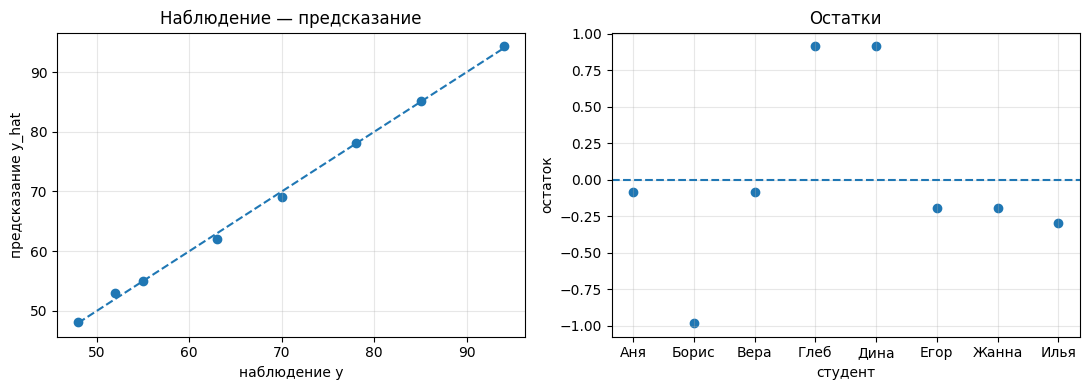

In [20]:
# Эта ячейка использует y_hat из задания 8.1.
residuals = y - y_hat
SSE = np.sum(residuals ** 2)
RMSE = np.sqrt(np.mean(residuals ** 2))
R2 = 1 - SSE / np.sum((y - y.mean()) ** 2)
print("residuals =", residuals)
print("SSE =", SSE)
print("RMSE =", RMSE)
print("R^2 =", R2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y, y_hat)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], linestyle="--")
axes[0].set_xlabel("наблюдение y")
axes[0].set_ylabel("предсказание y_hat")
axes[0].set_title("Наблюдение — предсказание")
axes[0].grid(alpha=0.3)

axes[1].axhline(0, linestyle="--")
axes[1].scatter(student_names, residuals)
axes[1].set_xlabel("студент")
axes[1].set_ylabel("остаток")
axes[1].set_title("Остатки")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Задание 8.3. Регрессия как проекция

- **[Python]** Проверьте условия

  $$
  \mathbf D^{\mathsf T}(\mathbf y-\widehat{\mathbf y})\approx\mathbf0,
  \qquad
  \widehat{\mathbf y}\in\mathcal R(\mathbf D).
  $$

- **[Интерпретация]** Закончите фразу: «Вектор предсказаний является проекцией вектора результатов на пространство, потому что…»

> **Граница очной части.** К этому моменту пройдена единая линия от координат вектора до модели наименьших квадратов. Все незавершённые задания 1–8 нужно закончить дома. Разделы 9 и 10 — обязательное домашнее продолжение, а не отдельная лабораторная.


#### Ваше решение

Проверка даёт $D^T(y-\hat y)\approx(0,0,0)^T$ (численно порядка $10^{-12}$). Следовательно, остаток ортогонален каждому столбцу $D$. Вектор предсказаний является проекцией вектора результатов на пространство, потому что он лежит в $\mathcal R(D)$ и имеет минимальное расстояние до $y$ среди всех векторов из этого пространства.

In [21]:
# Эта ячейка использует D и y_hat из задания 8.1.
orthogonality_check = D.T @ (y - y_hat)
print(orthogonality_check)

[0. 0. 0.]


## 9. Базовое PCA: новое направление вместо двух признаков


### Зачем это нужно

Часы практики и число выполненных комплектов в нашем наборе тесно связаны. PCA ищет ортонормированные направления, вдоль которых стандартизованные данные изменяются сильнее всего. Первое направление позволяет заменить два коррелирующих признака одной координатой, сохранив большую долю вариации.

Перед PCA признаки стандартизируются:

$$
Z_{ij}=\frac{X_{ij}-\mu_j}{s_j}.
$$

Затем строится ковариационная матрица

$$
\mathbf C=\frac{1}{n}\mathbf Z^{\mathsf T}\mathbf Z,
$$

а её собственные векторы задают главные направления:

$$
\mathbf C\mathbf u_k=\lambda_k\mathbf u_k.
$$

Доля объяснённой дисперсии компоненты равна

$$
r_k=\frac{\lambda_k}{\sum_j\lambda_j}.
$$

Собственные векторы и геометрию квадратичных форм см. на [с. 25–27](../02-linear-algebra/linear-algebra.pdf#page=25), стандартизацию и отбеливание — на [с. 27–28](../02-linear-algebra/linear-algebra.pdf#page=27).

![Геометрия собственных направлений](../02-linear-algebra/assets/figures/figure-06.png)

*Собственные векторы задают главные оси эллиптических линий уровня.*

![Стандартизация и отбеливание](../02-linear-algebra/assets/figures/figure-07.png)

*Переход от исходных признаков к стандартизованному и отбеленному представлению.*


### Задание 9.1. Выполнить готовый алгоритм

В ноутбуке уже дан код, который:

1. центрирует и стандартизирует $\mathbf X$;
2. строит $\mathbf C$;
3. получает собственные значения и векторы командой `np.linalg.eigh`;
4. сортирует компоненты по убыванию $\lambda_k$;
5. проектирует данные на первую компоненту;
6. восстанавливает приближение исходных признаков;
7. визуализирует исходные и восстановленные точки.

- **[Python]** Выполните готовые ячейки сверху вниз. Самостоятельная реализация PCA не требуется.
- **[Markdown]** Выпишите размерности $\mathbf X$, $\mathbf Z$, $\mathbf C$, матрицы собственных векторов и одномерных координат.
- **[Интерпретация]** Ответьте:
  1. какую долю вариации объясняет первая компонента;
  2. почему коэффициенты двух признаков в ней близки по модулю;
  3. какие студенты имеют крайние значения новой координаты;
  4. что потеряно при восстановлении по одной компоненте;
  5. почему одновременная смена знака собственного вектора и всех координат не меняет решения.


#### Ваше решение

Получены размерности: $X$ — $8\times2$, $Z$ — $8\times2$, $C$ — $2\times2$, матрица собственных векторов — $2\times2$, одномерные координаты `scores_1d` — $8\times1$.

Первая главная компонента объясняет примерно $99.383\%$ дисперсии, вторая — около $0.617\%$. Коэффициенты первой компоненты равны примерно $(0.7071,0.7071)$, поэтому оба признака вносят почти одинаковый вклад. Крайние значения новой координаты имеют Аня (минимум, около $-1.781$) и Илья (максимум, около $2.408$). При восстановлении по одной компоненте теряется небольшая часть различий между признаками: RMSE восстановления составляет около $0.189$ в исходных единицах. Знак собственного вектора можно одновременно поменять вместе со знаками координат: произведение при восстановлении останется тем же, поэтому решение не изменится.

Размерности: (8, 2) (8, 2) (2, 2) (2, 2) (8, 1)
Ковариационная матрица:
 [[1.     0.9877]
 [0.9877 1.    ]]
Собственные значения: [1.9877 0.0123]
Доли объяснённой дисперсии: [0.9938 0.0062]
Первая компонента: [0.7071 0.7071]


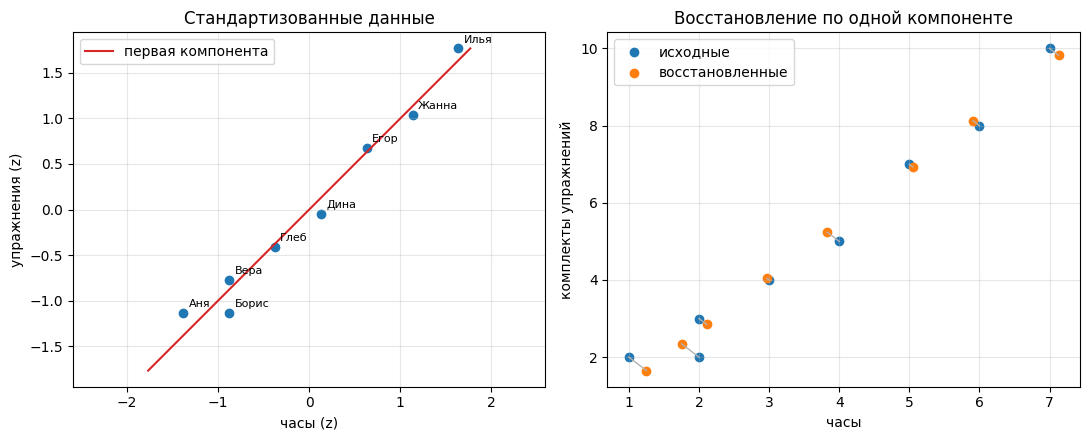

In [22]:
# Готовая реализация PCA: выполните её без изменений, затем интерпретируйте вывод.
mean_X = X.mean(axis=0)
scale_X = X.std(axis=0, ddof=0)
Z = (X - mean_X) / scale_X

C = Z.T @ Z / len(Z)
eigenvalues, eigenvectors = np.linalg.eigh(C)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]
explained_ratio = eigenvalues / eigenvalues.sum()

scores_1d = Z @ eigenvectors[:, :1]
Z_reconstructed = scores_1d @ eigenvectors[:, :1].T
X_reconstructed = Z_reconstructed * scale_X + mean_X

print("Размерности:", X.shape, Z.shape, C.shape, eigenvectors.shape, scores_1d.shape)
print("Ковариационная матрица:\n", C)
print("Собственные значения:", eigenvalues)
print("Доли объяснённой дисперсии:", explained_ratio)
print("Первая компонента:", eigenvectors[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].scatter(Z[:, 0], Z[:, 1], color="tab:blue")
for name, point in zip(student_names, Z):
    axes[0].annotate(name, point, xytext=(4, 4), textcoords="offset points", fontsize=8)
axis = np.linspace(-2.5, 2.5, 2)[:, None] * eigenvectors[:, 0]
axes[0].plot(axis[:, 0], axis[:, 1], color="tab:red", label="первая компонента")
axes[0].set_title("Стандартизованные данные")
axes[0].set_xlabel("часы (z)"); axes[0].set_ylabel("упражнения (z)")
axes[0].axis("equal"); axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].scatter(X[:, 0], X[:, 1], label="исходные", color="tab:blue")
axes[1].scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], label="восстановленные", color="tab:orange")
for original, restored in zip(X, X_reconstructed):
    axes[1].plot([original[0], restored[0]], [original[1], restored[1]], color="0.7", lw=1)
axes[1].set_title("Восстановление по одной компоненте")
axes[1].set_xlabel("часы"); axes[1].set_ylabel("комплекты упражнений")
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()


### Задание 9.2. Польза и ограничения

- **[Интерпретация]** Сформулируйте одним абзацем, когда сжатие двух признаков до одного полезно для визуализации или модели.
- **[Интерпретация]** Укажите не менее двух ограничений: PCA чувствителен к масштабу, описывает линейные направления и не использует целевой вектор $\mathbf y$ при выборе компонент.


#### Ваш ответ

Сжатие двух признаков до одной главной компоненты полезно, когда признаки сильно связаны и нужно уменьшить размерность, например для визуализации или как компактное представление перед дальнейшим анализом. В этих данных первая компонента объясняет около 99.38% дисперсии, поэтому потеря информации при таком сжатии небольшая. Ограничение PCA в том, что результат зависит от масштаба признаков, поэтому часто нужна стандартизация. Кроме того, PCA ищет только линейные направления максимальной дисперсии и не использует целевой вектор $y$, поэтому направление, важное для прогноза, не обязательно будет главным компонентом.

In [23]:
# Небольшая численная опора для ответа об ограничениях.
correlation = np.corrcoef(X.T)[0, 1]
reconstruction_rmse = np.sqrt(np.mean((X - X_reconstructed) ** 2))
print("Корреляция исходных признаков:", correlation)
print("RMSE восстановления по одной компоненте:", reconstruction_rmse)


Корреляция исходных признаков: 0.9876688294984395
RMSE восстановления по одной компоненте: 0.18867066835176535


## 10. Базовое SVD: малоранговое приближение изображения


### Зачем это нужно

Для любой матрицы $\mathbf A\in\mathbb R^{m\times n}$ сингулярное разложение имеет вид

$$
\mathbf A=\mathbf U\mathbf S\mathbf V^{\mathsf T}.
$$

Если оставить только первые $k$ сингулярных чисел и соответствующие столбцы, получится приближение ранга $k$:

$$
\mathbf A_k
=\mathbf U_{:,1:k}\mathbf S_{1:k,1:k}\mathbf V_{:,1:k}^{\mathsf T}.
$$

Оно хранит $k(m+n+1)$ чисел вместо $mn$. Чем больше $k$, тем точнее восстановление, но тем меньше выигрыш в объёме. Основы SVD см. на [с. 30–31](../02-linear-algebra/linear-algebra.pdf#page=30), усечённое SVD и оценку хранения — на [с. 33–34](../02-linear-algebra/linear-algebra.pdf#page=33).

![Малоранговые приближения изображения](../02-linear-algebra/assets/figures/figure-09.png)

*Оригинал и приближения рангов 2, 5 и 20 из теоретического пособия.*


### Задание 10.1. Выполнить готовое SVD

Ноутбук загружает верхнее левое изображение из рис. 9, переводит его в оттенки серого и выполняет `np.linalg.svd`. Для $k\in\{2,5,20,50\}$ готовый код строит восстановление и считает относительную ошибку Фробениуса

$$
\varepsilon_k=
\frac{\lVert\mathbf A-\mathbf A_k\rVert_F}{\lVert\mathbf A\rVert_F}.
$$

- **[Python]** Выполните готовый код и получите четыре изображения, ошибки и оценки хранения.
- **[Markdown]** Составьте таблицу со столбцами: ранг $k$, относительная ошибка, количество хранимых чисел, доля от исходного объёма.
- **[Интерпретация]** Опишите, какие структуры появляются уже при $k=2$, какие детали добавляются при $k=5$ и $k=20$, и насколько заметно улучшение при $k=50$.
- **[Интерпретация]** Проверьте, что ошибка не возрастает с ростом $k$. Объясните, почему это ожидаемо.


#### Ваше решение

После выполнения SVD для выбранного фрагмента изображения получены четыре приближения рангов $k=2,5,20,50$. Таблица с фактическими ошибками и объёмом хранения находится в выводе Python-ячейки. При увеличении $k$ сохраняется больше сингулярных компонент: при $k=2$ уже видны основные крупные структуры и контуры, при $k=5$ добавляется больше деталей, при $k=20$ изображение становится заметно ближе к оригиналу, а $k=50$ даёт дальнейшее улучшение, но с меньшей выгодой по объёму хранения.

Ошибка не возрастает при увеличении $k$: добавление следующих компонент не ухудшает наилучшее приближение, а может только сохранить прежнюю или уменьшить ошибку. Это соответствует свойству усечённого SVD.

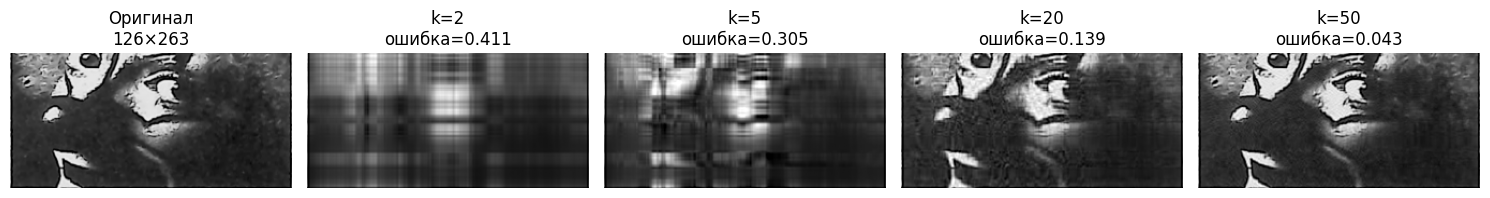

Исходное число значений: 33138
 k | отн. ошибка | хранить чисел | доля исходного
 2 |      0.41124 |           780 |        2.354%
 5 |      0.30479 |          1950 |        5.884%
20 |      0.13901 |          7800 |       23.538%
50 |      0.04309 |         19500 |       58.845%
Ошибка невозрастает: True


In [24]:
# Готовая демонстрация SVD на изображении из теоретического пособия.
figure = plt.imread("02-linear-algebra/assets/figures/figure-09.png")
gray = 0.2126 * figure[..., 0] + 0.7152 * figure[..., 1] + 0.0722 * figure[..., 2]

# Верхний левый фрагмент рис. 9; прореживание лишь уменьшает время вычисления.
image_matrix = gray[0:252:2, 55:581:2]
U, singular_values, Vt = np.linalg.svd(image_matrix, full_matrices=False)

ranks = [2, 5, 20, 50]
relative_errors = []
storage_numbers = []
m, n = image_matrix.shape

fig, axes = plt.subplots(1, 5, figsize=(15, 3.3))
axes[0].imshow(image_matrix, cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Оригинал\n{m}×{n}")
axes[0].axis("off")

for ax, k in zip(axes[1:], ranks):
    approximation = (U[:, :k] * singular_values[:k]) @ Vt[:k, :]
    error = np.linalg.norm(image_matrix - approximation, ord="fro") / np.linalg.norm(image_matrix, ord="fro")
    storage = k * (m + n + 1)
    relative_errors.append(error)
    storage_numbers.append(storage)
    ax.imshow(approximation, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"k={k}\nошибка={error:.3f}")
    ax.axis("off")

plt.tight_layout(); plt.show()

print("Исходное число значений:", m * n)
print(" k | отн. ошибка | хранить чисел | доля исходного")
for k, error, storage in zip(ranks, relative_errors, storage_numbers):
    print(f"{k:2d} | {error:12.5f} | {storage:13d} | {storage / (m*n):13.3%}")
print("Ошибка невозрастает:", np.all(np.diff(relative_errors) <= 1e-12))


### Задание 10.2. Связь PCA и SVD

В ноутбуке дополнительно выполняется SVD стандартизованной матрицы учебной активности $\mathbf Z$. Правые сингулярные векторы задают те же направления признаков, что и собственные векторы $\mathbf Z^{\mathsf T}\mathbf Z$.

- **[Python]** Сравните первый собственный вектор PCA с первой строкой $\mathbf V^{\mathsf T}$ с точностью до знака.
- **[Интерпретация]** Объясните результат без вывода формул: PCA описывает направления вариации данных, а SVD предоставляет удобный общий способ получить эти направления непосредственно из матрицы.


#### Ваше решение

Для стандартизованной матрицы $Z$ первая строка $V^T$ совпадает с первой главной компонентой PCA с точностью до знака. В данном запуске оба направления имеют вид примерно $(0.7071,0.7071)$, а модуль их скалярного произведения равен 1. PCA ищет направления максимальной вариации через собственные векторы $Z^TZ$, а SVD непосредственно раскладывает матрицу данных и выдаёт те же направления через правые сингулярные векторы. Поэтому SVD удобно использовать как общий вычислительный способ получения PCA-направлений.

In [25]:
# SVD той же стандартизованной матрицы Z, которая использовалась в PCA.
U_data, s_data, Vt_data = np.linalg.svd(Z, full_matrices=False)
pca_direction = eigenvectors[:, 0]
svd_direction = Vt_data[0]
agreement_up_to_sign = abs(pca_direction @ svd_direction)

print("Направление PCA:", pca_direction)
print("Направление SVD:", svd_direction)
print("|скалярное произведение|:", agreement_up_to_sign)
print("Сингулярные числа:", s_data)


Направление PCA: [0.7071 0.7071]
Направление SVD: [0.7071 0.7071]
|скалярное произведение|: 1.0
Сингулярные числа: [3.9876 0.3141]


## 11. Итоговая интерпретация


### Задание 11.1. Карта понятий

- **[Markdown]** Напишите связный текст из 8–12 предложений, использовав термины: *вектор наблюдения*, *матрица данных*, *линейное отображение*, *ранг*, *система уравнений*, *проекция*, *наименьшие квадраты*, *главная компонента*, *сингулярное число*, *малоранговое приближение*.
- **[Интерпретация]** Для каждого из трёх итоговых результатов — регрессия, PCA, SVD — укажите:
  1. какой объект подаётся на вход;
  2. какой объект получается на выходе;
  3. какую практическую пользу даёт результат;
  4. какая информация при этом может быть потеряна или неправильно истолкована.


#### Ваш ответ

Вектор наблюдения описывает один объект несколькими признаками, а строки таких векторов образуют матрицу данных. Линейное отображение переводит исходный вектор признаков в новый вектор через матрицу преобразования. Ранг показывает число независимых направлений и помогает понять, сколько информации матрица сохраняет. Система уравнений задаёт условия на неизвестный вектор, а проекция позволяет найти ближайший к данным вектор в выбранном линейном пространстве. Метод наименьших квадратов использует эту идею для построения регрессии: на вход поступают матрица признаков и целевой вектор, а на выходе получаются коэффициенты и предсказания. Главная компонента получает из матрицы признаков новое направление с максимальной дисперсией, поэтому PCA можно использовать для уменьшения размерности, но при этом часть информации теряется и направление не обязано быть лучшим для прогноза. Сингулярное число характеризует вклад соответствующего направления в SVD. Малоранговое приближение использует несколько наиболее значимых сингулярных чисел для сжатия матрицы или изображения, уменьшая объём хранения ценой потери деталей. Таким образом, регрессия ориентирована на связь признаков с $y$, PCA — на структуру вариации признаков, а SVD — на разложение самой матрицы; результаты всех трёх методов требуют осторожной интерпретации и не должны автоматически трактоваться как причинные зависимости.

## Что сдавать

Сдаётся заполненный студенческий ноутбук. Перед отправкой выполните все ячейки сверху вниз и убедитесь, что выводы сохранены.

Чек-лист:

- все задания **[Бумага]** перенесены в Markdown с промежуточными действиями;
- все ячейки **[Python]** выполняются без ошибок;
- размерности матриц указаны и согласованы;
- ответы **[Интерпретация]** относятся к конкретным полученным числам и графикам;
- невязка квадратной системы близка к нулю;
- для регрессии вычислены коэффициенты, остатки, SSE, RMSE и $R^2$;
- для PCA указана объяснённая дисперсия и разобрано восстановление;
- для SVD заполнена таблица рангов 2, 5, 20 и 50, а ошибка не возрастает;
- в последнем разделе дана единая связь между всеми этапами работы.


## Справка по синтаксису

В Markdown-ячейке формула внутри строки записывается как `$\mathbf y=\mathbf A\mathbf x$`, а отдельная формула — между двойными знаками доллара. В NumPy:

```python
A.shape                  # размерность массива
A.T                      # транспонирование
A @ B                    # матричное произведение
np.dot(a, b)             # скалярное произведение
np.linalg.norm(a)        # евклидова норма
np.linalg.det(A)         # определитель
np.linalg.matrix_rank(A) # ранг
np.linalg.solve(A, b)    # решение квадратной системы
np.linalg.lstsq(A, b, rcond=None)  # наименьшие квадраты
np.linalg.eigh(C)        # спектральное разложение симметричной матрицы
np.linalg.svd(A)         # сингулярное разложение
```

Все необходимые данные и изображения находятся в проекте; доступ к интернету не требуется.
